In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names


In [3]:
df = pd.DataFrame(X, columns=feature_names)
print("First five rows of the dataset:")
display(df.head())

First five rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)


In [5]:
pca = PCA()
X_pca = pca.fit_transform(X_std)


In [6]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)


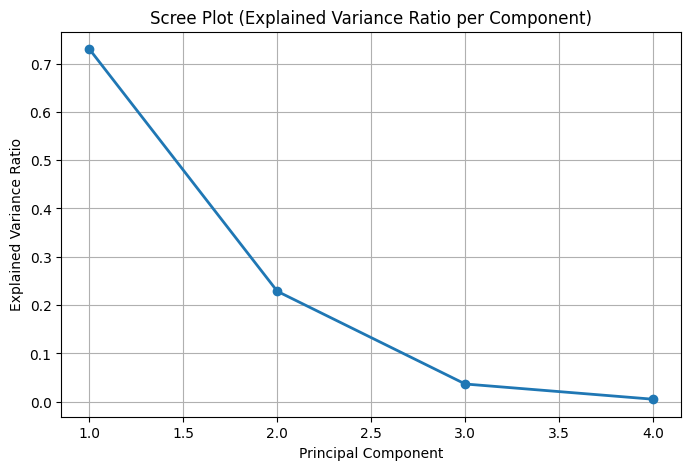

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-', linewidth=2)
plt.title('Scree Plot (Explained Variance Ratio per Component)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

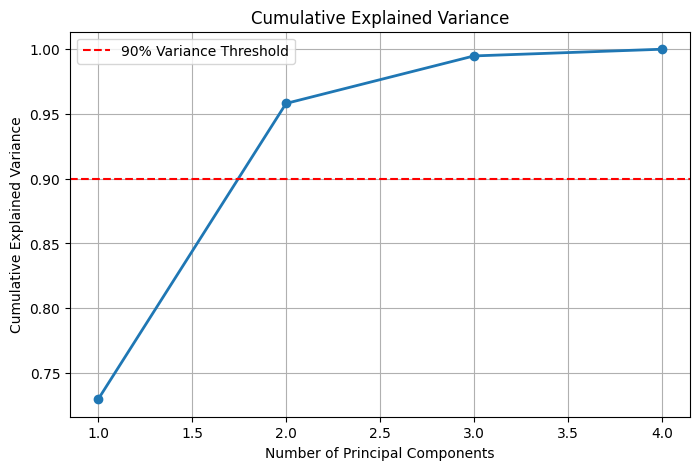

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, 'o-', linewidth=2)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
num_components_90 = np.argmax(cumulative_explained_variance >= 0.9) + 1
print(f"\nMinimum number of components required to retain at least 90% variance: {num_components_90}")



Minimum number of components required to retain at least 90% variance: 2


In [10]:
summary_df = pd.DataFrame({
    'Principal Component': np.arange(1, len(explained_variance_ratio)+1),
    'Explained Variance Ratio': explained_variance_ratio,
    'Cumulative Variance': cumulative_explained_variance
})
display(summary_df)


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,1,0.729624,0.729624
1,2,0.228508,0.958132
2,3,0.036689,0.994821
3,4,0.005179,1.000000
